# Analyse Surendettement - Plan Pret a Executer

Ce notebook produit une analyse rapide a partir de `data/processed/surendettement_unified.csv`:
- controle qualite
- metriques essentielles
- graphiques de tendance et comparaison


In [6]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('matplotlib') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'matplotlib'])

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)


In [1]:
from pathlib import Path
import pandas as pd

project_root = Path("/home/utilisateur/Documents/surendettement_analyse")
csv_path = project_root / "data/processed/surendettement_unified.csv"

if not csv_path.exists():
    raise FileNotFoundError(f"Fichier introuvable: {csv_path}")

df = pd.read_csv(csv_path)
print("Shape:", df.shape)
print("Colonnes:", list(df.columns))
df.head(10)


Shape: (321, 5)
Colonnes: ['year', 'region', 'indicator_name', 'value', 'source_file']


,year,region,indicator_name,value,source_file
0,1995,NaN,tableau_9_europe_14_le_cr_dit_laconsommation_e...,2001.0,bdf_1995_unknown.pdf
1,2000,NaN,nombre,2000.0,bdf_2000_unknown_1.pdf
2,2000,NaN,ensemble_base_7501,62.0,bdf_2000_unknown_1.pdf
3,2000,NaN,ensemble_base_7501,25.0,bdf_2000_unknown_1.pdf
4,2000,NaN,NaN,96.0,bdf_2000_unknown_1.pdf
5,2000,NaN,NaN,86.0,bdf_2000_unknown_1.pdf
6,2000,NaN,NaN,30.0,bdf_2000_unknown_1.pdf
7,2000,NaN,NaN,15.0,bdf_2000_unknown_1.pdf
8,2000,NaN,NaN,2.0,bdf_2000_unknown_1.pdf
9,2000,NaN,ensemble_base_305,79.0,bdf_2000_unknown_1.pdf


In [2]:
# Harmonisation minimale du schema (region -> departement si necessaire)
if 'departement' not in df.columns and 'region' in df.columns:
    df['departement'] = df['region']

required = ['year', 'departement', 'indicator_name', 'value', 'source_file']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Colonnes manquantes: {missing}')

df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
df['value'] = pd.to_numeric(df['value'], errors='coerce')
df['indicator_name'] = df['indicator_name'].fillna('unknown').astype(str).str.strip()
df['departement'] = df['departement'].fillna('unknown').astype(str).str.strip()

clean = df.dropna(subset=['year', 'value']).copy()
print('Lignes valides (year + value):', len(clean))
clean.head(5)


Lignes valides (year + value): 321


,year,region,indicator_name,value,source_file,departement
0,1995,NaN,tableau_9_europe_14_le_cr_dit_laconsommation_e...,2001.0,bdf_1995_unknown.pdf,unknown
1,2000,NaN,nombre,2000.0,bdf_2000_unknown_1.pdf,unknown
2,2000,NaN,ensemble_base_7501,62.0,bdf_2000_unknown_1.pdf,unknown
3,2000,NaN,ensemble_base_7501,25.0,bdf_2000_unknown_1.pdf,unknown
4,2000,NaN,unknown,96.0,bdf_2000_unknown_1.pdf,unknown


In [3]:
# 1) Controle qualite
quality = pd.DataFrame({
    'metric': [
        'rows_total',
        'rows_valid_year_value',
        'missing_year_pct',
        'missing_value_pct',
        'missing_indicator_pct',
        'missing_departement_pct'
    ],
    'value': [
        len(df),
        len(clean),
        round(df['year'].isna().mean() * 100, 2),
        round(df['value'].isna().mean() * 100, 2),
        round((df['indicator_name'] == 'unknown').mean() * 100, 2),
        round((df['departement'] == 'unknown').mean() * 100, 2),
    ]
})
quality


,metric,value
0,rows_total,321.00
1,rows_valid_year_value,321.00
2,missing_year_pct,0.00
3,missing_value_pct,0.00
4,missing_indicator_pct,1.56
5,missing_departement_pct,100.00


In [4]:
# 2) Metriques essentielles
kpis = {
    'nb_annees': int(clean['year'].nunique()),
    'annee_min': int(clean['year'].min()),
    'annee_max': int(clean['year'].max()),
    'nb_indicateurs': int(clean['indicator_name'].nunique()),
    'nb_departements': int(clean['departement'].nunique()),
    'somme_value': float(clean['value'].sum()),
    'moyenne_value': float(clean['value'].mean()),
    'mediane_value': float(clean['value'].median()),
}
pd.DataFrame({'kpi': list(kpis.keys()), 'value': list(kpis.values())})


,kpi,value
0,nb_annees,4.000000e+00
1,annee_min,1.995000e+03
2,annee_max,2.002000e+03
3,nb_indicateurs,2.600000e+01
4,nb_departements,1.000000e+00
5,somme_value,5.242486e+06
6,moyenne_value,1.633173e+04
7,mediane_value,1.000000e+02


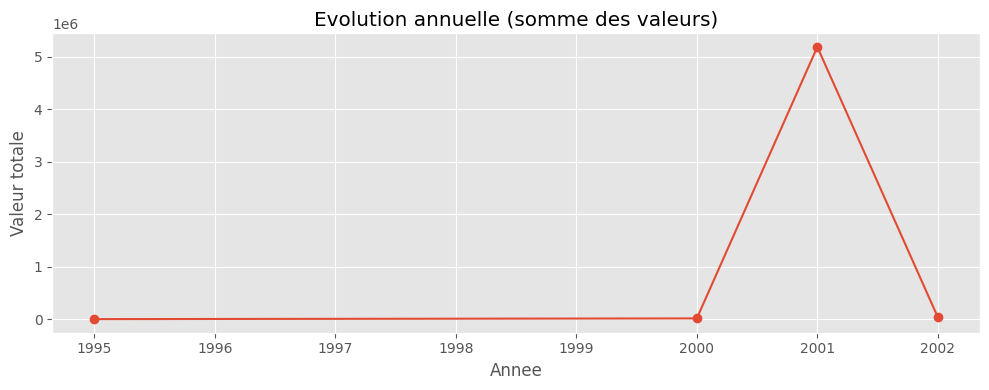

,year,value
0,1995,2001.0
1,2000,15423.0
2,2001,5186552.0
3,2002,38510.0


In [8]:
# 3) Graphique essentiel: total annuel
annual = clean.groupby('year', as_index=False)['value'].sum().sort_values('year')
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(annual['year'], annual['value'], marker='o')
ax.set_title('Evolution annuelle (somme des valeurs)')
ax.set_xlabel('Annee')
ax.set_ylabel('Valeur totale')
plt.tight_layout()
plt.show()
annual.tail(10)


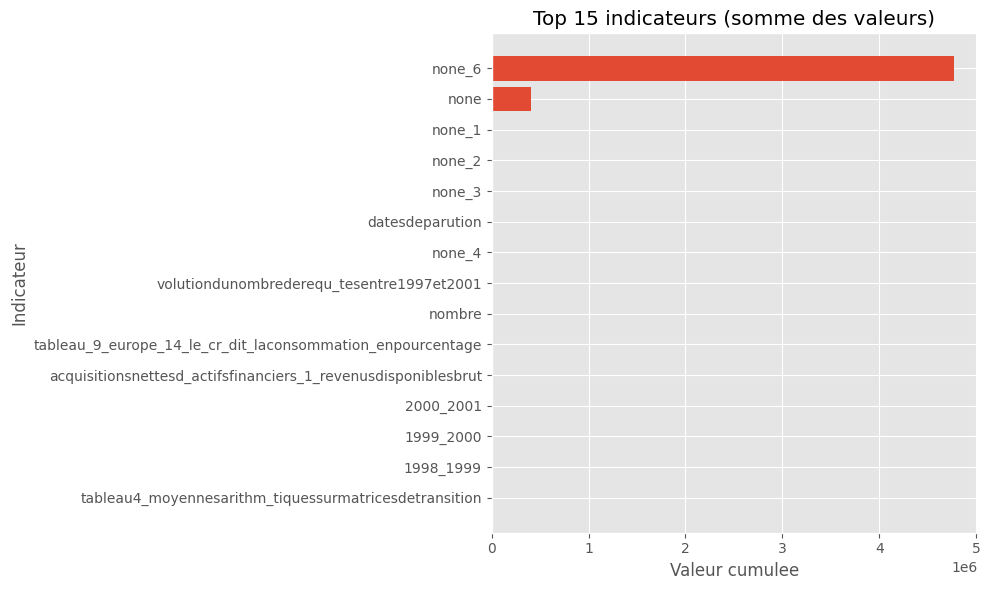

,indicator_name,value
19,none_6,4772150.0
14,none,403718.0
15,none_1,13770.0
16,none_2,11537.0
17,none_3,8016.0
9,datesdeparution,7962.0
18,none_4,6359.0
25,volutiondunombrederequ_tesentre1997et2001,5906.0
13,nombre,4001.0
23,tableau_9_europe_14_le_cr_dit_laconsommation_e...,2001.0


In [7]:
# 4) Graphique essentiel: Top indicateurs
top_indicators = (
    clean.groupby('indicator_name', as_index=False)['value'].sum()
    .sort_values('value', ascending=False)
    .head(15)
)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_indicators['indicator_name'][::-1], top_indicators['value'][::-1])
ax.set_title('Top 15 indicateurs (somme des valeurs)')
ax.set_xlabel('Valeur cumulee')
ax.set_ylabel('Indicateur')
plt.tight_layout()
plt.show()
top_indicators


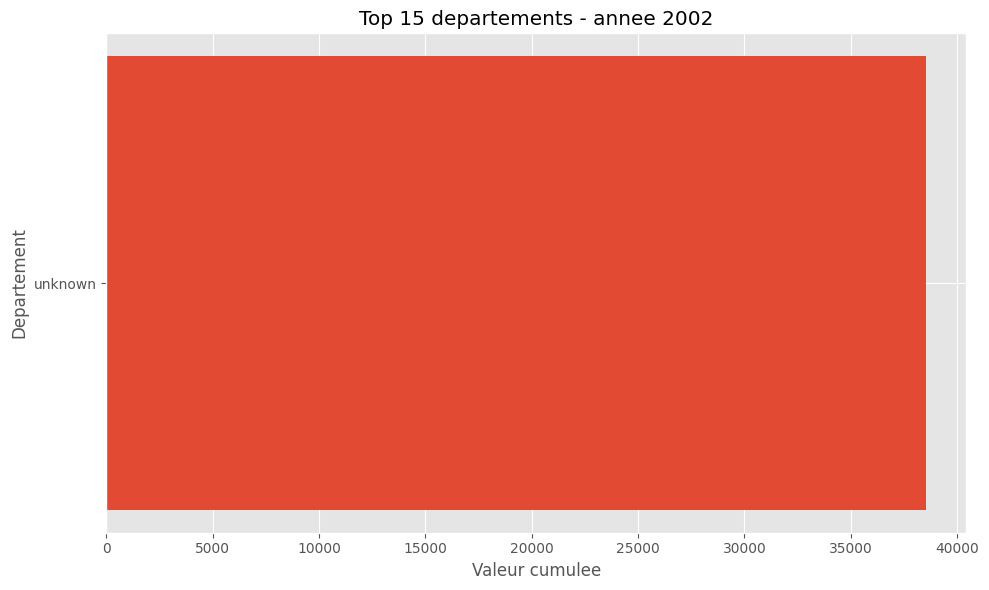

,departement,value
0,unknown,38510.0


In [9]:
# 5) Graphique essentiel: Top departements sur la derniere annee disponible
latest_year = int(clean['year'].max())
latest = clean[clean['year'] == latest_year]
top_dep = (
    latest.groupby('departement', as_index=False)['value'].sum()
    .sort_values('value', ascending=False)
    .head(15)
)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_dep['departement'][::-1], top_dep['value'][::-1])
ax.set_title(f'Top 15 departements - annee {latest_year}')
ax.set_xlabel('Valeur cumulee')
ax.set_ylabel('Departement')
plt.tight_layout()
plt.show()
top_dep


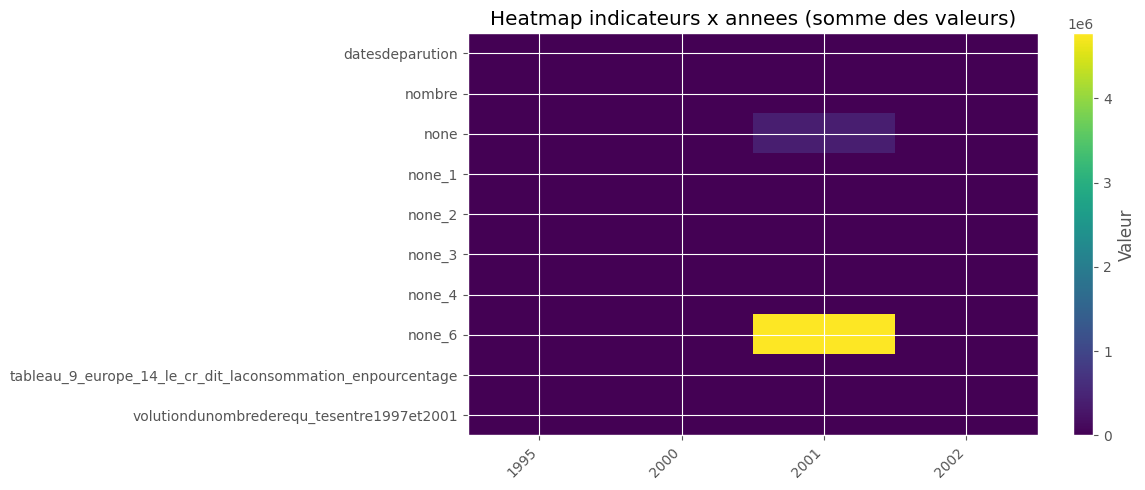

year,1995,2000,2001,2002
indicator_name,,,,
datesdeparution,0.0,7962.0,0.0,0.0
nombre,0.0,2000.0,2001.0,0.0
none,0.0,0.0,397090.0,6628.0
none_1,0.0,4845.0,1861.0,7064.0
none_2,0.0,0.0,3819.0,7718.0
none_3,0.0,0.0,0.0,8016.0
none_4,0.0,0.0,6359.0,0.0
none_6,0.0,0.0,4772150.0,0.0
tableau_9_europe_14_le_cr_dit_laconsommation_enpourcentage,2001.0,0.0,0.0,0.0


In [10]:
# 6) Graphique essentiel: heatmap indicateurs x annees (Top 10 indicateurs)
top10 = top_indicators['indicator_name'].head(10).tolist()
heat_df = clean[clean['indicator_name'].isin(top10)]
pivot = heat_df.pivot_table(index='indicator_name', columns='year', values='value', aggfunc='sum', fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot.values, aspect='auto')
ax.set_title('Heatmap indicateurs x annees (somme des valeurs)')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
fig.colorbar(im, ax=ax, label='Valeur')
plt.tight_layout()
plt.show()
pivot


## Prochaines analyses recommandees
- Filtrer sur un sous-ensemble d'indicateurs metier (dossiers deposes, recevables, etc.).
- Isoler des zones geographiques fiables (codes departements propres).
- Ajouter une prevision simple (1 a 3 ans) sur les indicateurs principaux.
